In [1]:
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

from StatTools.analysis.dfa import dfa
from StatTools.analysis.dpcca import dpcca
from StatTools.experimental.filters.symbolic_kalman import (
    get_sympy_filter_matrix,
    refine_filter_matrix,
)
from StatTools.filters.kalman_filter import KalmanFilter
from StatTools.generators.kasdin_generator import (
    ERKasdinGenerator,
    create_kasdin_generator,
)

                     RWI data
                        |
                        v
                Data distortion
                        |
                 /-------------\
                /               \
               v                 v
      Complete dataset   Distorted dataset x 5
            |                   |
       +----+----+         +----+----+
       |         |         |         |
       v         v         v         v
    Kalman     dplR     Kalman     dplR
       |         |         |         |
       +----+----+         +----+----+
            |                   |
            v                   v
     2 + 10 = 12 reconstructed signals

## 1. Real data analysis

In [2]:
DATA_DIR = Path(
    "research/kalman_filter/reconstruction_of_long_term_complex_system_dynamics/data"
)
DPLR_DIR = Path(
    "research/kalman_filter/reconstruction_of_long_term_complex_system_dynamics/dplR/results/dplr"
)
OUTPUT_DATA_DIR = DATA_DIR / "output"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
H_O = 1
df_rwi = pd.read_csv(os.path.join(DATA_DIR, "tree_rwi.csv"), index_col="year")

In [3]:
def tbrm(x, C=9.0):
    x = pd.Series(x).dropna().to_numpy(float)
    M = np.median(x)
    S = np.median(np.abs(x - M))
    u = (x - M) / (C * S + 1e-6)
    w = np.where(np.abs(u) <= 1, (1 - u**2)**2, 0.0)
    return math.fsum(w * x) / math.fsum(w)

In [4]:
# variant 1
drop_trees_list_1 = [
    "ff201a", "ff201b", "ff202a", "ff202b", "ff204a", "ff204b", "ff205a", "ff205b",
    "ff208a", "ff208b", "ff209a", "ff209b", "ff210a", "ff210b", "ff211a", "ff211b",
    "ff212a", "ff212b", "ff213a", "ff213b", "ff214a", "ff214b", "ff216a", "ff216b",
    "ff217a", "ff217b", "ff218a", "ff218b", "ff220a", "ff220b", "ff221a", "ff221b",
    "ff223a", "ff223b", "ff224a", "ff224b", "ff228a", "ff228b", "ff229a", "ff229b",
    "ff230a", "ff230b", "ff252a", "ff252b", "ff254a", "ff254b", "ff255a", "ff255b",
    "ff257b", "ff257c", "ff258a", "ff258b", "ff260b", "ff260c", "ff263a", "ff263b",
]

# variant 2
drop_trees_list_2 = [
    "ff201a", "ff201b", "ff203a", "ff203b", "ff205a", "ff205b", "ff207a", "ff207b",
    "ff208a", "ff208b", "ff210a", "ff210b", "ff211a", "ff211b", "ff212a", "ff212b",
    "ff213a", "ff213b", "ff214a", "ff214b", "ff216a", "ff216b", "ff218a", "ff218b",
    "ff220a", "ff220b", "ff221a", "ff221b", "ff222a", "ff222b", "ff223a", "ff223b",
    "ff225a", "ff225b", "ff228a", "ff228b", "ff229a", "ff229b", "ff230a", "ff230b",
    "ff254a", "ff254b", "ff255a", "ff255b", "ff256a", "ff256b", "ff257b", "ff257c",
    "ff258a", "ff258b", "ff260b", "ff260c", "ff263a", "ff263b",
]

# variant 3
drop_trees_list_3 = [
    "ff201a", "ff201b", "ff202a", "ff202b", "ff203a", "ff203b", "ff204a", "ff204b",
    "ff207a", "ff207b", "ff208a", "ff208b", "ff210a", "ff210b", "ff211a", "ff211b",
    "ff212a", "ff212b", "ff214a", "ff214b", "ff216a", "ff216b", "ff217a", "ff217b",
    "ff218a", "ff218b", "ff221a", "ff221b", "ff222a", "ff222b", "ff223a", "ff223b",
    "ff224a", "ff224b", "ff225a", "ff225b", "ff228a", "ff228b", "ff229a", "ff229b",
    "ff230a", "ff230b", "ff253a", "ff253c", "ff255a", "ff255b", "ff256a", "ff256b",
    "ff257b", "ff257c", "ff258a", "ff258b", "ff260b", "ff260c", "ff263a", "ff263b",
]

# variant 4
drop_trees_list_4 = [
    "ff201a", "ff201b", "ff202a", "ff202b", "ff203a", "ff203b", "ff204a", "ff204b",
    "ff205a", "ff205b", "ff207a", "ff207b", "ff208a", "ff208b", "ff209a", "ff209b",
    "ff210a", "ff210b", "ff211a", "ff211b", "ff212a", "ff212b", "ff213a", "ff213b",
    "ff214a", "ff214b", "ff216a", "ff216b", "ff217a", "ff217b", "ff218a", "ff218b",
    "ff221a", "ff221b", "ff222a", "ff222b", "ff223a", "ff223b", "ff224a", "ff224b",
    "ff225a", "ff225b", "ff228a", "ff228b", "ff229a", "ff229b", "ff252a", "ff252b",
    "ff253a", "ff253c", "ff254a", "ff254b", "ff255a", "ff255b", "ff257b", "ff257c",
    "ff258a", "ff258b", "ff260b", "ff260c",
]

# variant 5
drop_trees_list_5 = [
    "ff202a", "ff202b", "ff203a", "ff203b", "ff204a", "ff204b", "ff205a", "ff205b",
    "ff207a", "ff207b", "ff208a", "ff208b", "ff209a", "ff209b", "ff210a", "ff210b",
    "ff211a", "ff211b", "ff213a", "ff213b", "ff214a", "ff214b", "ff216a", "ff216b",
    "ff217a", "ff217b", "ff218a", "ff218b", "ff221a", "ff221b", "ff222a", "ff222b",
    "ff223a", "ff223b", "ff224a", "ff224b", "ff225a", "ff225b", "ff228a", "ff228b",
    "ff229a", "ff229b", "ff230a", "ff230b", "ff252a", "ff252b", "ff253a", "ff253c",
    "ff256a", "ff256b", "ff257b", "ff257c", "ff258a", "ff258b", "ff260b", "ff260c",
    "ff263a", "ff263b",
]


# All 5 distortion variants. Plots further below keep showing DROP_VARIANT only,
# metrics/tables/FF are collected across all N_VARIANTS.
drop_trees_lists = {
    1: drop_trees_list_1,
    2: drop_trees_list_2,
    3: drop_trees_list_3,
    4: drop_trees_list_4,
    5: drop_trees_list_5,
}
N_VARIANTS = len(drop_trees_lists)
DROP_VARIANT = 3

drop_trees_list = drop_trees_lists[DROP_VARIANT]
drop_trees = set(drop_trees_list)

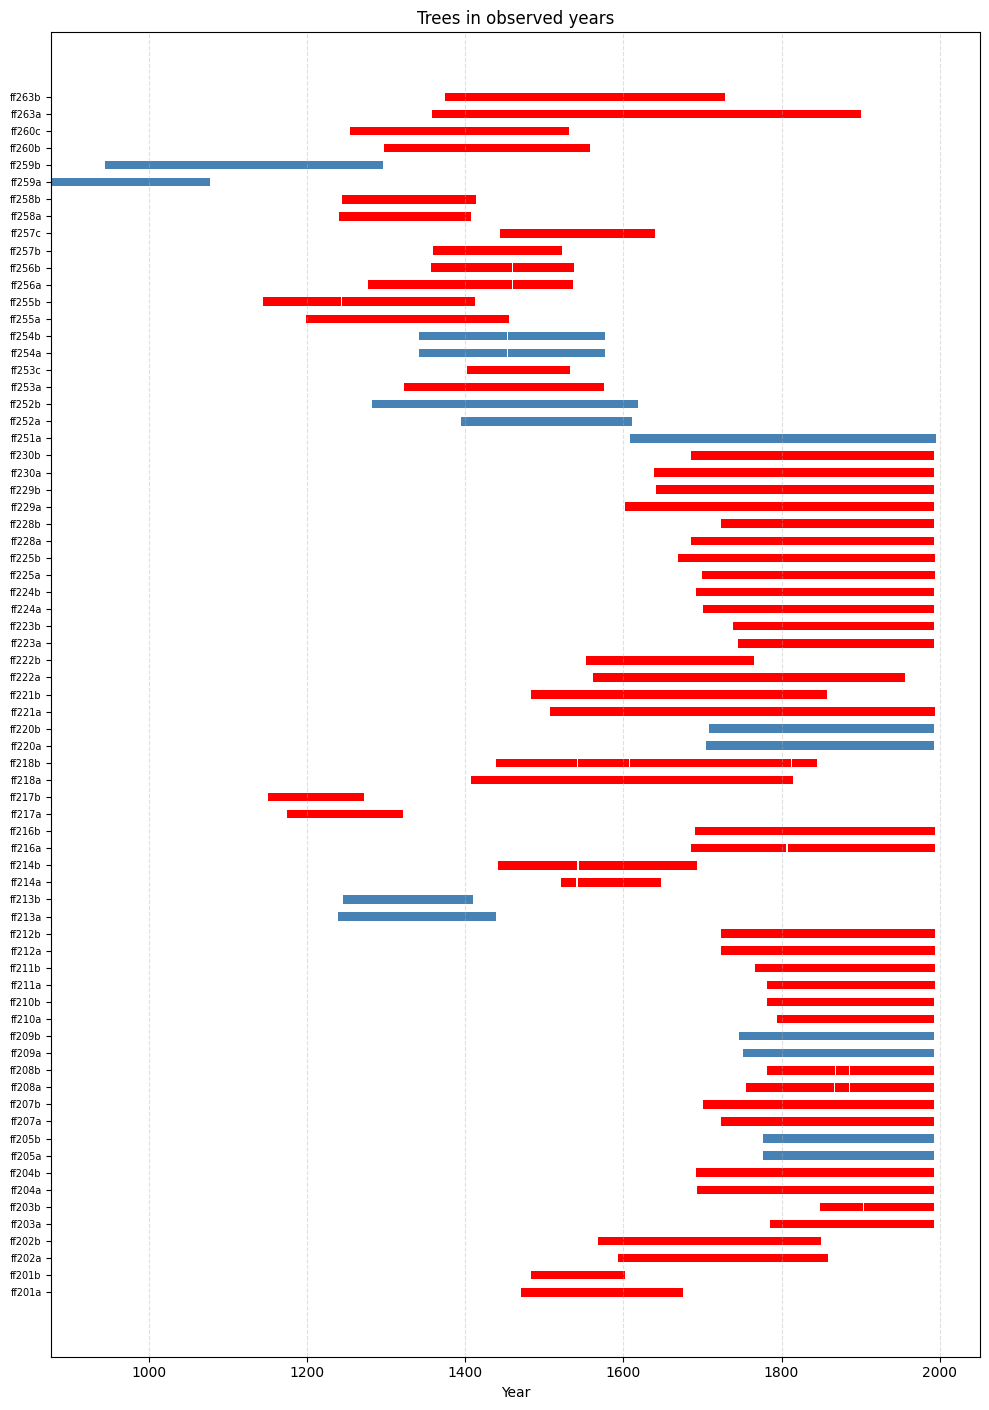

In [5]:
trees = df_rwi.columns.tolist()
n_trees = len(trees)
color = "steelblue"
fig, ax = plt.subplots(figsize=(10, max(6, n_trees * 0.2)))

for i, tree in enumerate(trees):
    if tree in drop_trees:
        color = "r"
    else:
        color = "steelblue"

    valid_years = df_rwi.index[df_rwi[tree].notna()].tolist()
    if not valid_years:
        continue
    segments = []
    start = valid_years[0]
    prev = valid_years[0]
    for y in valid_years[1:]:
        if y - prev > 1:
            segments.append((start, prev))
            start = y
        prev = y
    segments.append((start, prev))
    for seg_start, seg_end in segments:
        ax.barh(i, seg_end - seg_start + 1, left=seg_start, height=0.5, color=color)

ax.set_yticks(range(n_trees))
ax.set_yticklabels(trees, fontsize=7)
ax.set_xlabel("Year")
ax.set_title("Trees in observed years")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / "tree_data_drop.svg")
plt.savefig(OUTPUT_DATA_DIR / "tree_data_drop.png")
plt.show()

In [6]:
all_years = np.arange(df_rwi.index.min(), df_rwi.index.max() + 1)
df_full = df_rwi.reindex(all_years)  # no data → NaN

data = df_full.to_numpy()  # shape: (n_years, n_trees)
years = df_full.index.to_numpy()
n_years = len(years)
total_years = years[-1] - years[0] + 1

print(f"trees: {data.shape[1]}, years: {data.shape[0]} ({years[0]}–{years[-1]})")
print(f"dtype: {data.dtype}, NaN: {np.isnan(data).sum()}")

trees: 71, years: 1118 (877–1994)
dtype: float64, NaN: 60636


Median: 16 trees per year
Min / Max: 1 / 42
Median lenght: 258 years
Min / Max lenght: 119 / 543 years


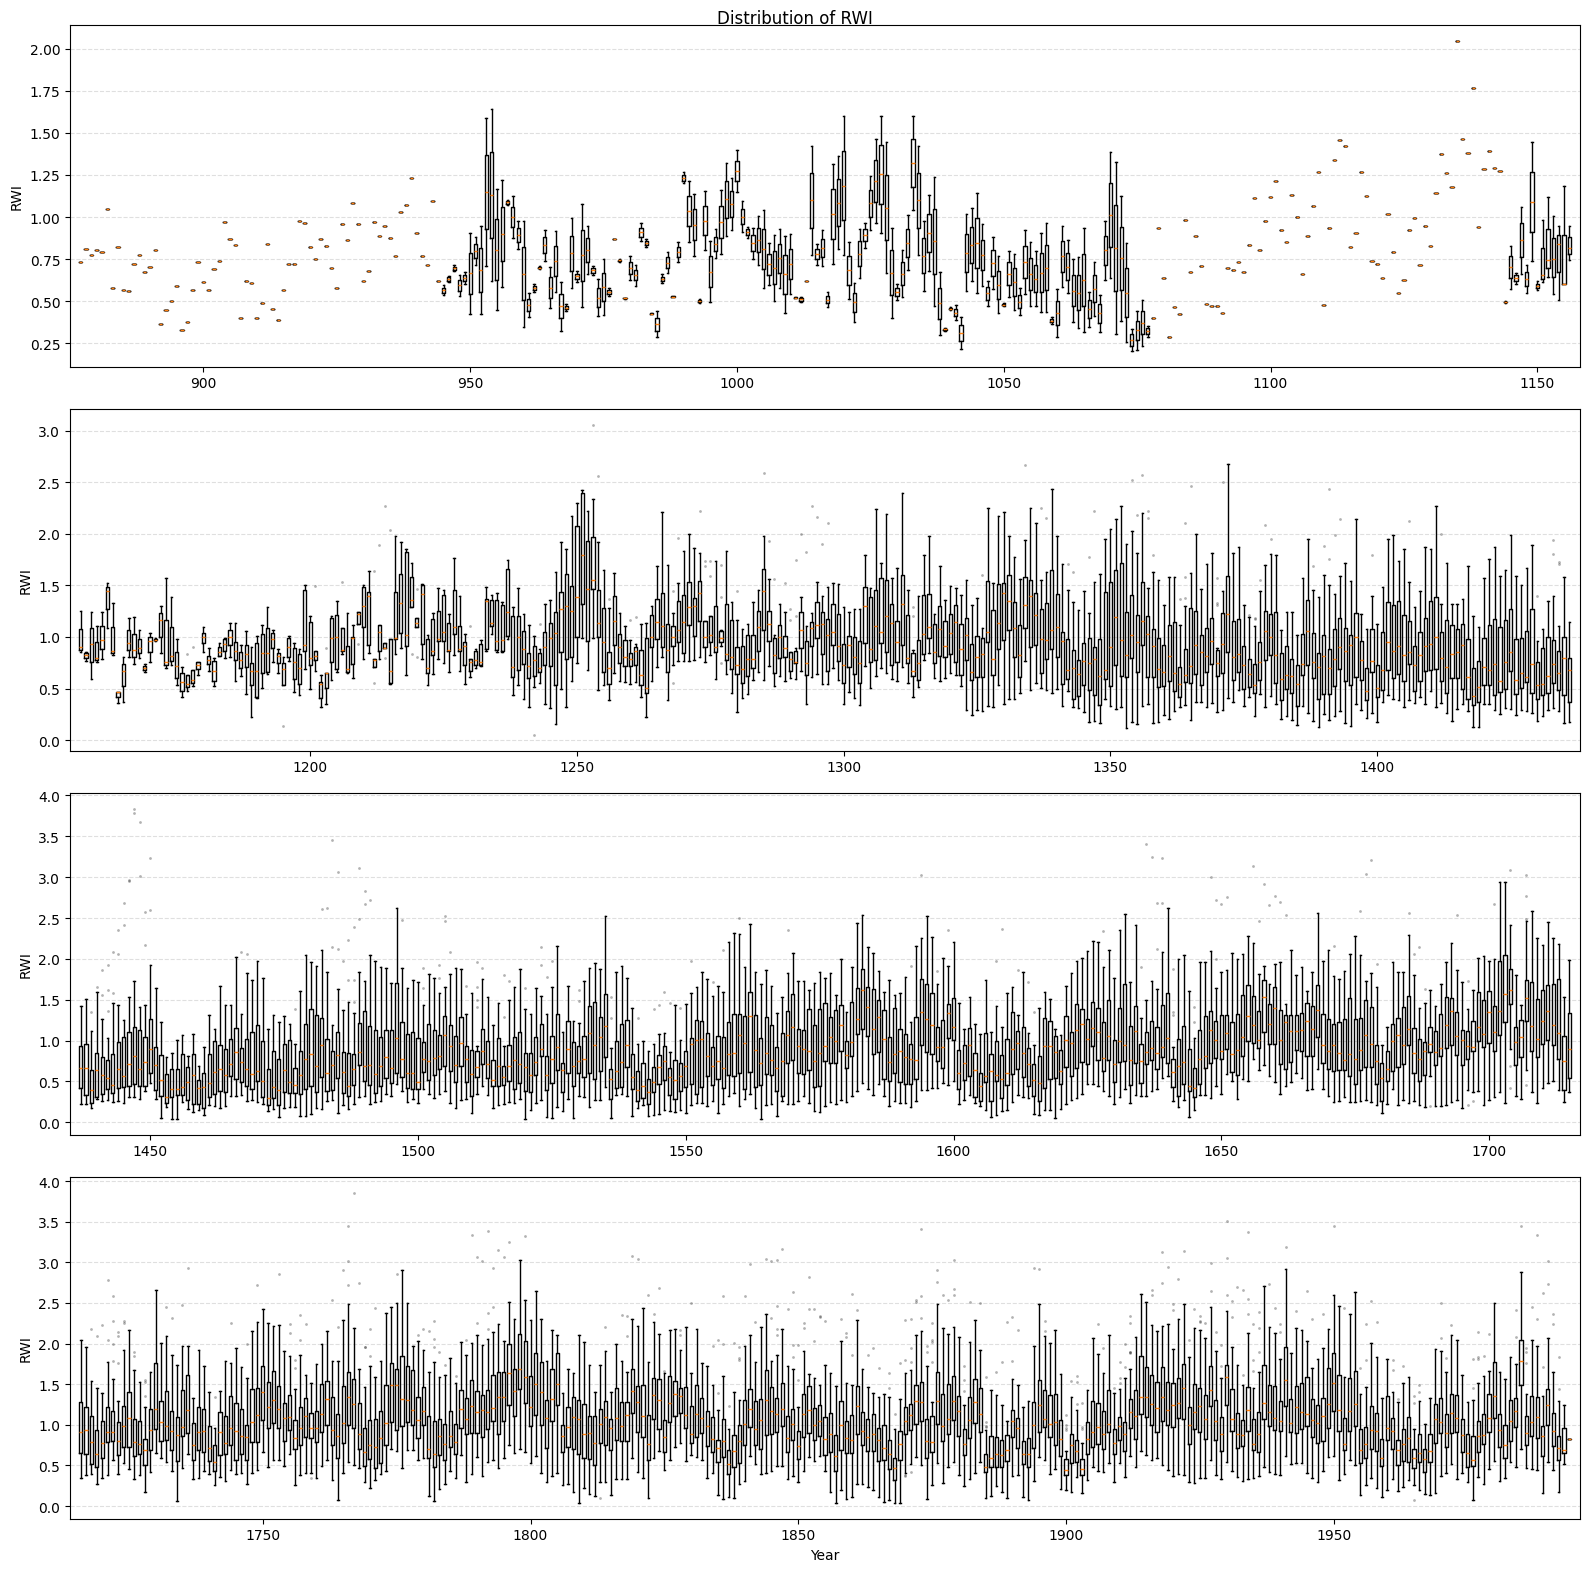

In [7]:
valid_mask = ~np.all(np.isnan(data), axis=1)
valid_idx = np.where(valid_mask)[0]
box_data = [data[i][~np.isnan(data[i])] for i in valid_idx]
valid_years_bp = years[valid_idx]

n_rows = 4
chunks = np.array_split(np.arange(len(valid_idx)), n_rows)

trees_per_year = np.array([len(box_data[j]) for j in range(len(valid_idx))])
median_sample = int(np.median(trees_per_year))
print(f"Median: {median_sample} trees per year")
print(f"Min / Max: {trees_per_year.min()} / {trees_per_year.max()}")
series_lengths = np.sum(~np.isnan(data), axis=0)
print(f"Median lenght: {int(np.median(series_lengths))} years")
print(f"Min / Max lenght: {series_lengths.min()} / {series_lengths.max()} years")

fig, axes = plt.subplots(n_rows, 1, figsize=(16, 4 * n_rows))
for ax, chunk in zip(axes, chunks):
    ax.boxplot(
        [box_data[j] for j in chunk],
        positions=valid_years_bp[chunk],
        widths=0.6,
        manage_ticks=False,
        flierprops={"marker":".", "markersize":2, "alpha":0.3},
    )
    ax.set_xlim(valid_years_bp[chunk[0]] - 2, valid_years_bp[chunk[-1]] + 2)
    ax.set_ylabel("RWI")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Year")
fig.suptitle("Distribution of RWI")
plt.tight_layout()
plt.show()

## 2. Applying the Kalman filter

In [8]:
def normalize(data: np.ndarray[np.float64]) -> np.ndarray[np.float64]:
    mean = np.nanmean(data)
    std = np.nanstd(data)
    return (data - mean) / std if std != 0 else (data - mean)


def get_F_matrix(order: int, H_O: np.array, length: int) -> np.array:
    generator = create_kasdin_generator(H_O, length=length)
    ar_filter = generator.get_filter_coefficients()
    number_matrix = refine_filter_matrix(
        get_sympy_filter_matrix(order), order, ar_filter
    )
    number_matrix = np.array(number_matrix, dtype=np.float64)
    return number_matrix


def get_Q_matrix(order: int, H_O: np.array, length: int) -> np.array:
    model_generator = ERKasdinGenerator(H_O, length=length)
    model_signal = model_generator.get_full_sequence()
    signal = normalize(model_signal)
    ridge = 1e-6 * np.var(signal)
    Q = np.eye(order) * ridge
    Q[0, 0] = np.var(signal)
    return Q


def get_H_matrix(order: int) -> np.array:
    H = np.zeros(order)
    H[0] = 1
    return H


def get_R_matrix(points):
    return np.array([[np.nanvar(points)]])


def init_kf(H_O, noise, method, order, length):
    F = get_F_matrix(order, H_O, length)
    H = get_H_matrix(order)
    if isinstance(noise, (np.ndarray, list)):
        R = get_R_matrix(noise)
    else:
        R = np.array([[noise]])
    Q = get_Q_matrix(order, H_O, length)

    kf = KalmanFilter(order, 1, F=F, H=H, R=R, Q=Q)
    return kf

### Data distortion

In [9]:
df_distorted = df_full.copy().drop(
    drop_trees_list,
    axis=1,
)
data_distorted = df_distorted.to_numpy()
mean_signal_distorted = np.zeros(n_years)
for i, year in enumerate(data_distorted):
    mean_signal_distorted[i] = tbrm(year)

In [10]:
print(
    f"trees: {data_distorted.shape[1]}, years: {data_distorted.shape[0]} ({years[0]}–{years[-1]})"
)
print(f"dtype: {data_distorted.dtype}, NaN: {np.isnan(data_distorted).sum()}")

trees: 15, years: 1118 (877–1994)
dtype: float64, NaN: 12950


In [11]:
all_years = df_full.index
total_by_year = df_full.notna().sum(axis=1)
distorted_by_year = df_distorted.notna().sum(axis=1).reindex(all_years, fill_value=0)
pct_by_year = (distorted_by_year / total_by_year.replace(0, pd.NA) * 100).fillna(0)

trees_stats = pd.DataFrame(
    {
        "total": total_by_year,
        "remaining": distorted_by_year,
        "pct": pct_by_year.round(1),
    }
)

min_pct = trees_stats["pct"].min()
min_year = trees_stats["pct"].idxmin()
print(f"\nMin: {min_pct:.1f}%")
print(f"Median: {np.median(trees_stats['pct']):.1f}%")


Min: 4.0%
Median: 23.5%


### Filtering

In [12]:
order = 8
method = "Kasdin"

mean_signal_full = np.zeros(total_years)
for i, year in enumerate(data):
    mean_signal_full[i] = tbrm(year)
kalman_signal_full = np.zeros(total_years)
kf = init_kf(H_O, 0, method, order, total_years)

for i, year in enumerate(data):
    valid = year[~np.isnan(year)]
    if valid.size != 0:
        year_mean = tbrm(valid)
        R = get_R_matrix(valid)
        kf._R = R
    else:
        year_mean = None
    kf.predict()
    kf.adjust(np.array([[year_mean]]))
    kalman_signal_full[i] = kf.get_current_measurement().item()


kalman_signal_distorted = np.zeros(total_years)
kf = init_kf(H_O, 0, method, order, total_years)

for i, year in enumerate(data_distorted):
    valid = year[~np.isnan(year)]
    if valid.size != 0:
        year_mean = tbrm(valid)
        R = get_R_matrix(valid)
        kf._R = R
    else:
        year_mean = None
    kf.predict()
    kf.adjust(np.array([[year_mean]]))
    kalman_signal_distorted[i] = kf.get_current_measurement().item()

## 3. Checking the Hurst exponent

In [13]:
# Load dplR data
df_rwi_dplr = pd.read_csv(
    os.path.join(DPLR_DIR, "tree_rwi_dplr_71.csv"), index_col="year"
)
df_rwi_dplr_distorted = pd.read_csv(
    os.path.join(DPLR_DIR, "tree_rwi_dplr_3.csv"), index_col="year"
)

trees = df_rwi_dplr.columns.tolist()
n_trees = len(trees)

all_years = np.arange(df_rwi_dplr.index.min(), df_rwi_dplr.index.max() + 1)
df_full_drpl = df_rwi_dplr.reindex(all_years)

data_dplr = df_full_drpl.to_numpy()
years = df_full_drpl.index.to_numpy()
n_years = len(years)
total_years = years[-1] - years[0] + 1

dplr_signal_full = np.zeros(total_years)
for i, year in enumerate(data_dplr):
    dplr_signal_full[i] = tbrm(year)

print(
    f"trees: {data_dplr.shape[1]}, years: {data_dplr.shape[0]} ({years[0]}–{years[-1]})"
)
print(f"dtype: {data_dplr.dtype}, NaN: {np.isnan(data_dplr).sum()}")


trees = df_rwi_dplr_distorted.columns.tolist()
n_trees = len(trees)

all_years = np.arange(
    df_rwi_dplr_distorted.index.min(), df_rwi_dplr_distorted.index.max() + 1
)
df_full_drpl_distorted = df_rwi_dplr_distorted.reindex(all_years)

data_dplr_distorted = df_full_drpl_distorted.to_numpy()
years = df_full_drpl_distorted.index.to_numpy()
n_years = len(years)
total_years = years[-1] - years[0] + 1

dplr_signal_distorted = np.zeros(total_years)
for i, year in enumerate(data_dplr_distorted):
    dplr_signal_distorted[i] = tbrm(year)

print(
    f"trees: {data_dplr_distorted.shape[1]}, years: {data_dplr_distorted.shape[0]} ({years[0]}–{years[-1]})"
)
print(f"dtype: {data_dplr_distorted.dtype}, NaN: {np.isnan(data_dplr_distorted).sum()}")

trees: 71, years: 1118 (877–1994)
dtype: float64, NaN: 60636
trees: 15, years: 1118 (877–1994)
dtype: float64, NaN: 12950


### Distortion across the 5 variants

In [14]:
def run_kalman_filter(data_matrix, H_O, order, length, noise=0, method="Kasdin"):
    signal = np.zeros(length)
    kf = init_kf(H_O, noise, method, order, length)
    for i, year in enumerate(data_matrix):
        valid = year[~np.isnan(year)]
        if valid.size != 0:
            year_mean = tbrm(valid)
            kf._R = get_R_matrix(valid)
        else:
            year_mean = None
        kf.predict()
        kf.adjust(np.array([[year_mean]]))
        signal[i] = kf.get_current_measurement().item()
    return signal


def find_dplr_file(kept_columns):
    """Locate the dplR reconstruction whose kept tree columns match a variant.

    tree_rwi_dplr_<N>.csv files are produced by Preprocess_rwl.R with N being
    the number of surviving series -- not the variant index -- so variants
    are matched by comparing the actual column sets.
    """
    kept = set(kept_columns)
    for path in sorted(DPLR_DIR.glob("tree_rwi_dplr_*.csv")):
        if "tree_rwi_dplr_71" in path.name:
            continue
        cols = set(pd.read_csv(path, index_col="year", nrows=0).columns)
        if cols == kept:
            return path
    return None


years_full = df_full.index.to_numpy()
total_years_full = len(years_full)

variant_results = {}
missing_dplr_variants = []

for v in range(1, N_VARIANTS + 1):
    drop_list_v = drop_trees_lists[v]
    df_distorted_v = df_full.drop(columns=drop_list_v)
    data_distorted_v = df_distorted_v.to_numpy()

    mean_signal_v = np.array([tbrm(year) for year in data_distorted_v])
    kalman_signal_v = run_kalman_filter(
        data_distorted_v, H_O, order, total_years_full, method=method
    )

    kept_columns_v = set(df_full.columns) - set(drop_list_v)
    dplr_path_v = find_dplr_file(kept_columns_v)
    if dplr_path_v is not None:
        df_dplr_v = pd.read_csv(dplr_path_v, index_col="year").reindex(years_full)
        dplr_signal_v = np.array([tbrm(year) for year in df_dplr_v.to_numpy()])
    else:
        dplr_signal_v = None
        missing_dplr_variants.append(v)

    variant_results[v] = {
        "mean": mean_signal_v,
        "kalman": kalman_signal_v,
        "dplr": dplr_signal_v,
    }

if missing_dplr_variants:
    print(
        f"No dplR reconstruction found in {DPLR_DIR} for variant(s); these "
        f"variants are skipped in dplR-based metrics until then."
    )

In [15]:
def _compute_h(sig, start_inx=0, finish_inx=-1):
    sig = np.array(sig)
    s_vals, f2_vals = dfa(sig, degree=2, processes=1)
    log_s = np.log(s_vals)
    log_f = np.log(np.sqrt(f2_vals))
    return round(
        stats.linregress(
            log_s[start_inx:finish_inx], log_f[start_inx:finish_inx]
        ).slope,
        3,
    )

In [16]:
H0 = _compute_h(mean_signal_full)
Hr_kalman_full = _compute_h(kalman_signal_full)
Hr_dplr_full = _compute_h(dplr_signal_full)

hurst_rows = []
for v in range(1, N_VARIANTS + 1):
    res = variant_results[v]
    hurst_rows.append(
        {
            "variant": v,
            "H0": H0,
            "H0_hat": _compute_h(res["mean"]),
            f"Hr_{method}{order}": Hr_kalman_full,
            f"Hr_hat_{method}{order}": _compute_h(res["kalman"]),
            "Hr_dplR": Hr_dplr_full,
            "Hr_hat_dplR": (
                _compute_h(res["dplr"]) if res["dplr"] is not None else np.nan
            ),
        }
    )

df_hurst = pd.DataFrame(hurst_rows).set_index("variant")
df_hurst

,H0,H0_hat,Hr_Kasdin8,Hr_hat_Kasdin8,Hr_dplR,Hr_hat_dplR
variant,,,,,,
1,0.941,1.012,0.976,1.039,0.94,0.915
2,0.941,0.924,0.976,0.954,0.94,0.953
3,0.941,0.977,0.976,0.998,0.94,0.929
4,0.941,0.973,0.976,0.990,0.94,0.963
5,0.941,0.937,0.976,0.965,0.94,0.946


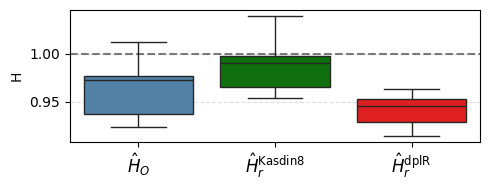

In [17]:
hurst_box_cols = ["H0_hat", f"Hr_hat_{method}{order}", "Hr_hat_dplR"]
df_hurst_box = df_hurst[hurst_box_cols].melt(var_name="estimate", value_name="H").dropna()
hurst_palette = {
    "H0_hat": "steelblue",
    f"Hr_hat_{method}{order}": "green",
    "Hr_hat_dplR": "red",
}
hurst_labels = {
    "H0_hat": r"$\hat{H}_O$",
    f"Hr_hat_{method}{order}": rf"$\hat{{H}}_r^{{\mathrm{{{method}{order}}}}}$",
    "Hr_hat_dplR": r"$\hat{H}_r^{\mathrm{dplR}}$",
}

fig, ax = plt.subplots(figsize=(5, 2))
sns.boxplot(
    data=df_hurst_box,
    x="estimate",
    y="H",
    order=hurst_box_cols,
    hue="estimate",
    hue_order=hurst_box_cols,
    palette=hurst_palette,
    legend=False,
    dodge=False,
    ax=ax,
)
ax.axhline(1, color="k", linestyle="--", alpha=0.5, label="$H_O$")
ax.set_xlabel("")
ax.set_ylabel("H")
ax.set_xticks(range(len(hurst_box_cols)))
ax.set_xticklabels([hurst_labels[c] for c in hurst_box_cols], fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / "hurst_boxplot.png")
plt.savefig(OUTPUT_DATA_DIR / "hurst_boxplot.svg")
plt.show()

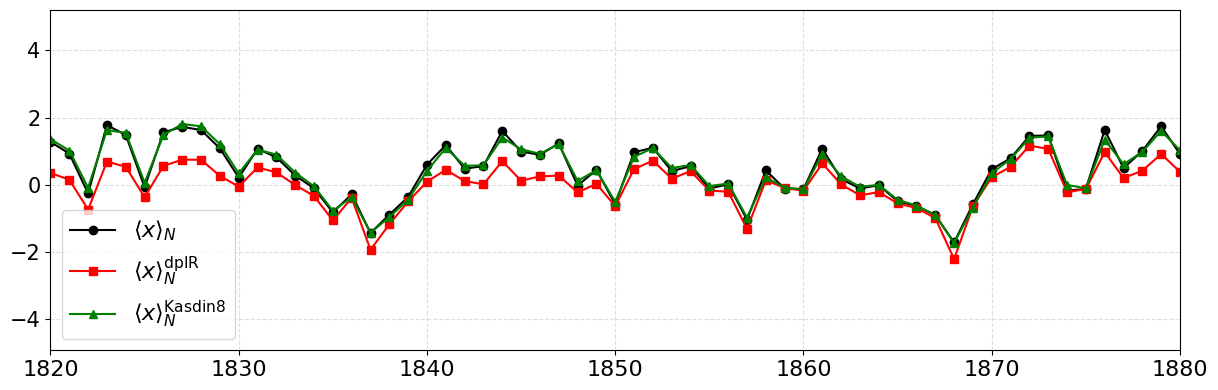

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(years, normalize(mean_signal_full), "-o", label="$\\langle x \\rangle_N$", color="k")
plt.plot(
    years,
    normalize(dplr_signal_full),
    "-s",
    color="r",
    label="$\\langle x \\rangle_N^\\text{dplR}$",
)
plt.plot(
    years,
    normalize(kalman_signal_full),
    "-^",
    color="green",
    label=f"$\\langle x \\rangle_N^\\text{{{method}{order}}}$",
)
plt.grid(linestyle="--", alpha=0.4)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / "recovered_full.png")
plt.savefig(OUTPUT_DATA_DIR / "recovered_full.svg")
plt.xlim(1820, 1880)
plt.savefig(OUTPUT_DATA_DIR / "recovered.png")
plt.savefig(OUTPUT_DATA_DIR / "recovered.svg")
plt.show()

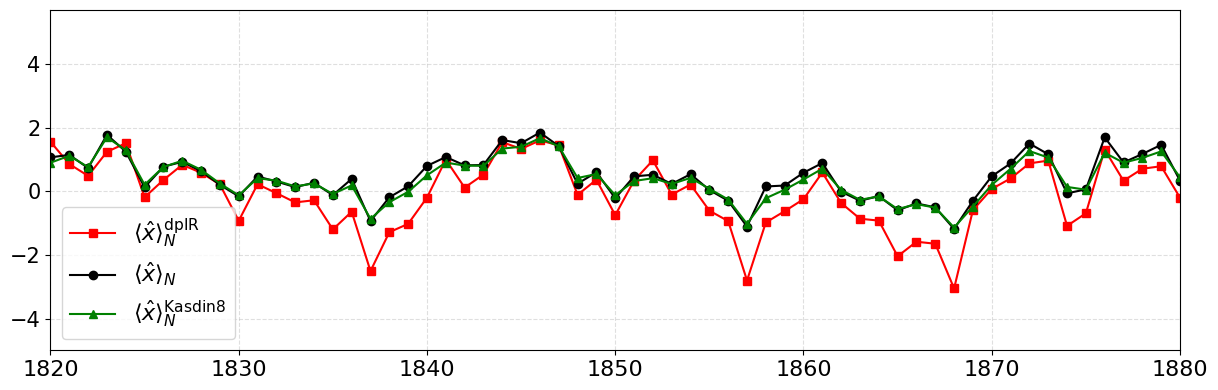

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(
    years,
    normalize(dplr_signal_distorted),
    "-s",
    color="r",
    label="$\\langle \\hat{x} \\rangle_N^\\text{dplR}$",
)
plt.plot(
    years,
    normalize(mean_signal_distorted),
    "-o",
    label="$\\langle \\hat{x} \\rangle_N$",
    color="k",
)
plt.plot(
    years,
    normalize(kalman_signal_distorted),
    "-^",
    color="green",
    label=f"$\\langle \\hat{{x}} \\rangle_N^\\text{{{method}{order}}}$",
)
plt.grid(linestyle="--", alpha=0.4)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / "recovered_distorted_full.png")
plt.savefig(OUTPUT_DATA_DIR / "recovered_distorted_full.svg")
plt.xlim(1820, 1880)
plt.savefig(OUTPUT_DATA_DIR / "recovered_distorted.png")
plt.savefig(OUTPUT_DATA_DIR / "recovered_distorted.svg")
plt.show()

## 4. Checking the FF

In [20]:
scales_full = np.array([2**i for i in range(3, 9)])
scales = np.array([2**i for i in range(3, 9)])
scales_fit = np.array([2**i for i in range(3, 8)])
threads = 8

tab_colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
]

In [21]:
def plot_ff(signal_groups, save_name, show_fit_region=False, legend_fontsize=None):
    """Fluctuation function averaged (mean +/- 2*std) over an ensemble of signals.

    signal_groups: dict mapping a legend label -> ndarray of shape
    (n_signals, n_years), e.g. the reconstructions from the N_VARIANTS
    distortion variants for one method (Kalman or dplR).
    """
    _, ax = plt.subplots(figsize=(6, 8))
    ff_mean = None
    for color_index, (label, signals) in enumerate(signal_groups.items()):
        signals = np.atleast_2d(np.asarray(signals))

        _, _, f2, s = dpcca(
            signals, 2, 1, scales_full, processes=threads, n_integral=1
        )

        diag_ff = np.diagonal(f2, axis1=1, axis2=2)
        diag_ff = np.where(diag_ff == 0, np.nan, diag_ff)

        ff = np.sqrt(diag_ff)
        ff /= ff[0, :]

        ff_mean = np.nanmean(ff, axis=1)
        sigma = np.nanstd(ff, axis=1)

        if show_fit_region:
            ax.axvspan(
                scales_fit[0] - 10**2 * 3,
                scales_fit[-1] + 10**5 / 2,
                facecolor="grey",
                alpha=0.1,
            )

        ax.plot(
            s,
            ff_mean,
            c=tab_colors[color_index + 2],
            label=label,
        )
        ax.errorbar(
            s,
            ff_mean,
            yerr=2 * sigma,
            fmt="none",
            c=tab_colors[color_index + 2],
            capsize=4,
        )

    for i, H1 in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
        y0 = ff_mean[0]
        ref = y0 * (scales_full / scales_full[0]) ** H1

        plt.loglog(
            scales_full,
            ref,
            color=tab_colors[i],
            linestyle="--",
            label=f"$H=${H1}",
            alpha=0.5,
        )

    plt.grid(which="both")
    if legend_fontsize is not None:
        plt.legend(fontsize=legend_fontsize)
        plt.xticks(fontsize=legend_fontsize)
        plt.yticks(fontsize=legend_fontsize)
    else:
        plt.legend()

    plt.savefig(OUTPUT_DATA_DIR / f"{save_name}.png", bbox_inches="tight")
    plt.savefig(OUTPUT_DATA_DIR / f"{save_name}.svg", bbox_inches="tight")
    plt.show()

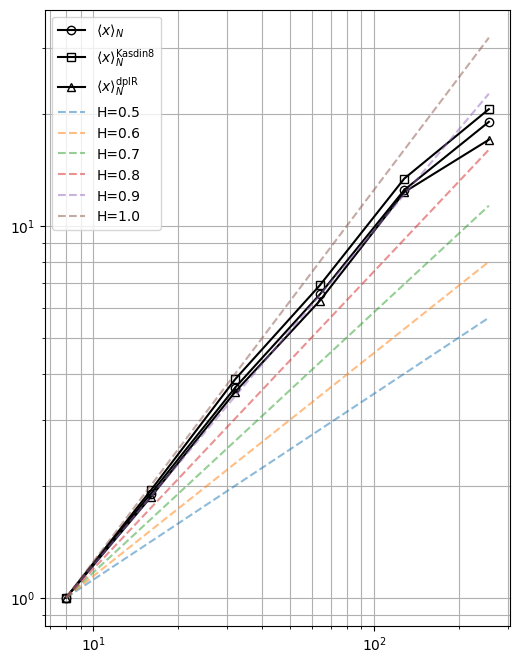

In [22]:
fig, ax = plt.subplots(figsize=(6, 8))
for signal, label, marker in [
    (mean_signal_full, "$\\langle x \\rangle_N$", "o"),
    (kalman_signal_full, f"$\\langle x \\rangle_N^\\text{{{method}{order}}}$", "s"),
    (dplr_signal_full, "$\\langle x \\rangle_N^\\text{dplR}$", "^"),
]:
    _, _, f2, s = dpcca(signal, 2, 1, scales, processes=threads, n_integral=1)
    ff = np.sqrt(f2)
    ff /= ff[0]

    ax.plot(
        s,
        ff,
        c="k",
        label=label,
        marker=marker,
        markerfacecolor="none",
        markeredgecolor="k",
    )


tab_colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
]

for i, H1 in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    y0 = ff[0]
    ref = y0 * (scales / scales[0]) ** H1

    plt.loglog(
        scales,
        ref,
        color=tab_colors[i],
        linestyle="--",
        label=f"H={H1}",
        alpha=0.5,
    )
plt.grid(which="both")
plt.legend()
plt.savefig(OUTPUT_DATA_DIR / "ff_tree.png", bbox_inches="tight")
plt.savefig(OUTPUT_DATA_DIR / "ff_tree.svg", bbox_inches="tight")
plt.show()

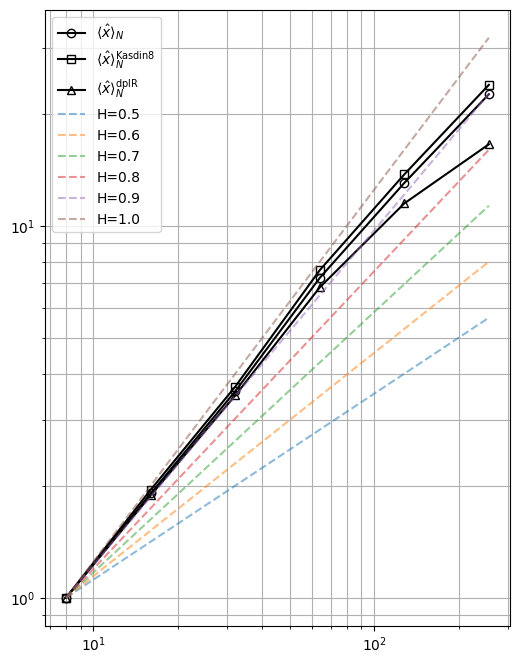

In [23]:
fig, ax = plt.subplots(figsize=(6, 8))
for signal, label, marker in [
    (mean_signal_distorted, "$\\langle \\hat{x} \\rangle_N$", "o"),
    (
        kalman_signal_distorted,
        f"$\\langle \\hat{{x}} \\rangle_N^\\text{{{method}{order}}}$",
        "s",
    ),
    (dplr_signal_distorted, "$\\langle \\hat{x} \\rangle_N^\\text{dplR}$", "^"),
]:
    _, _, f2, s = dpcca(signal, 2, 1, scales, processes=threads, n_integral=1)
    ff = np.sqrt(f2)
    ff /= ff[0]

    ax.plot(
        s,
        ff,
        c="k",
        label=label,
        marker=marker,
        markerfacecolor="none",
        markeredgecolor="k",
    )


tab_colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
]

for i, H1 in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    y0 = ff[0]
    ref = y0 * (scales / scales[0]) ** H1

    plt.loglog(
        scales,
        ref,
        color=tab_colors[i],
        linestyle="--",
        label=f"H={H1}",
        alpha=0.5,
    )
plt.grid(which="both")
plt.legend()
plt.savefig(OUTPUT_DATA_DIR / "ff_tree_noisy.png", bbox_inches="tight")
plt.savefig(OUTPUT_DATA_DIR / "ff_tree_noisy.svg", bbox_inches="tight")
plt.show()

### FF averaged over the 5 variants

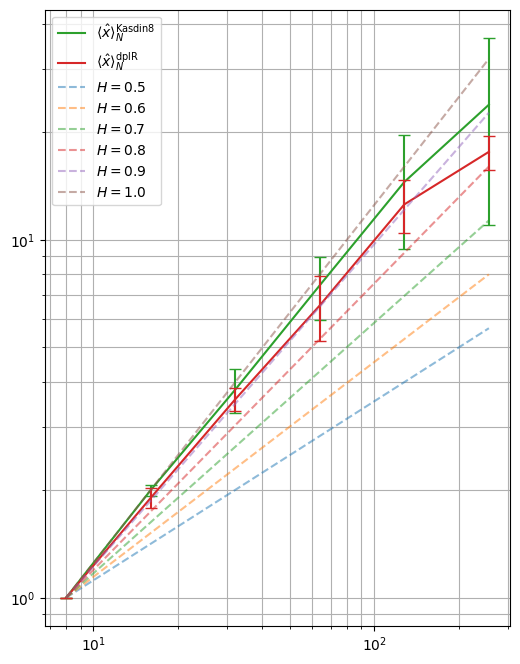

In [24]:
kalman_variants_used = list(range(1, N_VARIANTS + 1))
dplr_variants_used = [
    v for v in range(1, N_VARIANTS + 1) if variant_results[v]["dplr"] is not None
]

kalman_stack = np.array([variant_results[v]["kalman"] for v in kalman_variants_used])
dplr_stack = np.array([variant_results[v]["dplr"] for v in dplr_variants_used])

plot_ff(
    {
        f"$\\langle \\hat{{x}} \\rangle_N^\\text{{{method}{order}}}$": kalman_stack,
        f"$\\langle \\hat{{x}} \\rangle_N^\\text{{dplR}}$": dplr_stack,
    },
    save_name="ff_tree_variants",
)

## 5. Checking the ACF

In [25]:
N_LAGS = 300

In [26]:
def integrated_acf_error(acf_true, acf_estimated, max_lag=None):
    if max_lag is None:
        max_lag = min(len(acf_true), len(acf_estimated))
    err = np.mean(np.abs(acf_true[:max_lag] - acf_estimated[:max_lag]))
    return err


def get_rq(signal):
    signal = signal - np.median(signal)
    crossings = []
    for i in range(1, len(signal)):
        if (signal[i - 1] < 0 and signal[i] >= 0) or (signal[i - 1] > 0 and signal[i] <= 0):
            crossings.append(i)
    r = np.diff(np.array(crossings)).astype(float)
    return np.mean(r)

In [27]:
acf_mean = acf(mean_signal_full, nlags=N_LAGS)
acf_kalman = acf(kalman_signal_full, nlags=N_LAGS)
acf_dplr = acf(dplr_signal_full, nlags=N_LAGS)

In [28]:
err_kalman = integrated_acf_error(acf_mean, acf_kalman, max_lag=N_LAGS)
err_dplr = integrated_acf_error(acf_mean, acf_dplr, max_lag=N_LAGS)
print(f"err_kalman: {err_kalman:.4f}")
print(f"err_dplr: {err_dplr:.4f}")

err_kalman: 0.0091
err_dplr: 0.1027


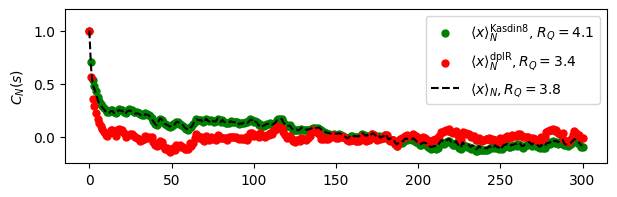

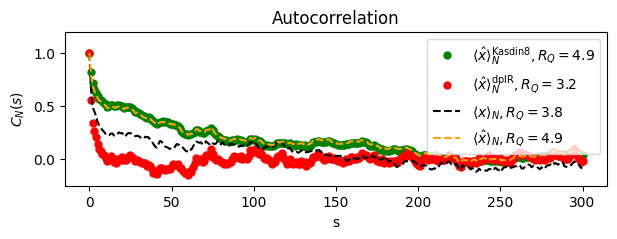

In [29]:
fig, ax = plt.subplots(figsize=(7, 2))
plot_acf(
    kalman_signal_full,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    alpha=None,
    color="green",
    label=f"$\\langle x \\rangle_N^\\text{{{method}{order}}}$, $R_Q=${get_rq(kalman_signal_full):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    dplr_signal_full,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    color="r",
    alpha=None,
    label=f"$\\langle x \\rangle_N^\\text{{dplR}}, R_Q=${get_rq(dplr_signal_full):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal_full,
    lags=N_LAGS,
    ax=ax,
    color="k",
    alpha=None,
    marker="",
    linestyle="--",
    label=f"$\\langle x \\rangle_N, R_Q=${get_rq(mean_signal_full):.1f}",
    use_vlines=False,
    title=None,
)

plt.ylabel("$C_N(s)$")
plt.ylim(-0.25, 1.2)
plt.legend()
plt.savefig(OUTPUT_DATA_DIR / "acf_trees.png")
plt.savefig(OUTPUT_DATA_DIR / "acf_trees.svg")
plt.show()


fig, ax = plt.subplots(figsize=(7, 2))
plot_acf(
    kalman_signal_distorted,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    color="green",
    alpha=None,
    label=f"$\\langle \\hat{{x}} \\rangle_N^\\text{{{method}{order}}}, R_Q=${get_rq(kalman_signal_distorted):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    dplr_signal_distorted,
    lags=N_LAGS,
    ax=ax,
    marker="o",
    color="r",
    alpha=None,
    label=f"$\\langle \\hat{{x}} \\rangle_N^\\text{{dplR}}, R_Q=${get_rq(dplr_signal_distorted):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal_full,
    color="k",
    marker="",
    linestyle="--",
    alpha=None,
    lags=N_LAGS,
    ax=ax,
    label=f"$\\langle x \\rangle_N, R_Q=${get_rq(mean_signal_full):.1f}",
    use_vlines=False,
    title=None,
)
plot_acf(
    mean_signal_distorted,
    lags=N_LAGS,
    ax=ax,
    marker="",
    color="orange",
    linestyle="--",
    alpha=None,
    label=f"$\\langle \\hat{{x}} \\rangle_N, R_Q=${get_rq(mean_signal_distorted):.1f}",
    use_vlines=False,
)
plt.xlabel("s")
plt.ylabel("$C_N(s)$")
plt.ylim(-0.25, 1.2)
plt.legend()
plt.savefig(OUTPUT_DATA_DIR / "acf_trees_distorted.png")
plt.savefig(OUTPUT_DATA_DIR / "acf_trees_distorted.svg")
plt.show()

## 6. Checking MSE and Pearson correlation

In [30]:
def mse(reference: np.ndarray, signal: np.ndarray) -> float:
    return float(np.mean((np.asarray(reference) - np.asarray(signal)) ** 2))

signals = {
    f"{method}{order}": kalman_signal_full,
    "dplR": dplr_signal_full,
}
for v in range(1, N_VARIANTS + 1):
    res = variant_results[v]
    signals[f"{method}{order}, distorted v{v}"] = res["kalman"]
    if res["dplr"] is not None:
        signals[f"dplR, distorted v{v}"] = res["dplr"]

metrics = []
for name, signal in signals.items():
    r, p_value = stats.pearsonr(normalize(mean_signal_full), normalize(signal))
    metrics.append(
        {
            "signal": name,
            "pearson_r": round(r, 3),
            "p_value": round(p_value, 5),
            "mse": round(mse(normalize(mean_signal_full), normalize(signal)), 3),
        }
    )

df_metrics = pd.DataFrame(metrics).set_index("signal")
df_metrics

,pearson_r,p_value,mse
signal,,,
Kasdin8,0.996,0.0,0.009
dplR,0.763,0.0,0.475
"Kasdin8, distorted v1",0.776,0.0,0.447
"dplR, distorted v1",0.628,0.0,0.743
"Kasdin8, distorted v2",0.860,0.0,0.280
"dplR, distorted v2",0.709,0.0,0.581
"Kasdin8, distorted v3",0.711,0.0,0.579
"dplR, distorted v3",0.703,0.0,0.595
"Kasdin8, distorted v4",0.699,0.0,0.601


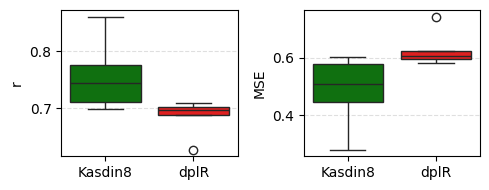

In [31]:
df_metrics_variants = df_metrics.reset_index()
df_metrics_variants = df_metrics_variants[
    df_metrics_variants["signal"].str.contains("distorted")
]
df_metrics_variants["variant_method"] = df_metrics_variants["signal"].str.split(
    ","
).str[0]
box_methods = df_metrics_variants["variant_method"].unique().tolist()
box_palette = {f"{method}{order}": "green", "dplR": "red"}
ylabels = {"pearson_r": "r", "mse": "MSE"}

fig, axes = plt.subplots(1, 2, figsize=(5, 2))
for ax, col in zip(axes, ["pearson_r", "mse"]):
    sns.boxplot(
        data=df_metrics_variants,
        x="variant_method",
        y=col,
        order=box_methods,
        hue="variant_method",
        hue_order=box_methods,
        palette=box_palette,
        legend=False,
        dodge=False,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabels[col])
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DATA_DIR / "metrics_boxplot.png")
plt.savefig(OUTPUT_DATA_DIR / "metrics_boxplot.svg")
plt.show()